In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn pulp

Unable to create process using 'C:\Users\Parnavi Wanare\anaconda3\python.exe "C:\Users\Parnavi Wanare\anaconda3\Scripts\pip-script.py" install pandas numpy matplotlib seaborn scikit-learn pulp'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_excel("ML_dataset .xlsx")
df.head()

,State,Year,Total IPC Crimes,Population\n(Lakhs),Violent Crimes,Property Crimes,Cyber Crimes,Crimes vs Women,Conviction\nRate (%),Sanctioned\nPolice,Actual\nPolice,Vacancy\n(%),Police Per\nLakh,Police Budget\n(Cr),★ Region,Violent\n(%),Property\n(%),Cyber\n(%),Women\n(%),★ Risk\nCategory
0,A&N Islands,2019,564,4.0,116,70,2,135,72.4,2748,2107,23.3,526.75,224,East,20.57,12.41,0.35,23.94,Low
1,Andhra Pradesh,2019,119229,523.2,7670,15508,1886,17746,60.2,75616,59041,21.9,112.85,4820,South,6.43,13.01,1.58,14.88,Medium
2,Arunachal Pradesh,2019,2590,15.1,678,743,8,317,68.3,14428,11214,22.3,742.65,768,North-East,26.18,28.69,0.31,12.24,Low
3,Assam,2019,123512,344.2,28696,23565,2231,30025,52.1,67450,58027,14.0,168.59,4120,North-East,23.23,19.08,1.81,24.31,Medium
4,Bihar,2019,197935,1201.1,45004,42359,1050,18587,34.2,97920,81253,17.0,67.65,6840,East,22.74,21.40,0.53,9.39,High


In [4]:
df.columns = df.columns.str.strip().str.replace("\n", " ")

df.rename(columns={
    "Population (Lakhs)": "Population",
    "Conviction Rate (%)": "ConvictionRate",
    "Vacancy (%)": "Vacancy",
    "Police Per Lakh": "PolicePerLakh",
    "Police Budget (Cr)": "Budget"
}, inplace=True)

In [7]:
# Crime Rate
df["CrimeRate"] = df["Total IPC Crimes"] / df["Population"]

# Crime Growth
df["CrimeGrowth"] = df.groupby("State")["CrimeRate"].pct_change()

# Lag Feature (ONLY lag1)
df["CrimeRate_lag1"] = df.groupby("State")["CrimeRate"].shift(1)

# Budget per capita
df["BudgetPerCapita"] = df["Budget"] / df["Population"]

# Infrastructure Index
df["InfraIndex"] = (
    df["PolicePerLakh"] * 0.4 +
    (100 - df["Vacancy"]) * 0.4 +
    df["ConvictionRate"] * 0.2
)

# Fill missing values instead of dropping
df["CrimeGrowth"] = df["CrimeGrowth"].fillna(0)

# Target (next year crime)
df["Target"] = df.groupby("State")["CrimeRate"].shift(-1)

# Keep only valid rows (IMPORTANT FIX)
df = df[df["CrimeRate_lag1"].notna()]
df = df[df["Target"].notna()]

# Fill remaining NaNs safely
df = df.fillna(0)

In [27]:
print("Total rows:", len(df))
print(df["Year"].value_counts())

Total rows: 108
Year
2020    36
2021    36
2022    36
Name: count, dtype: int64


In [9]:
train = df[df["Year"] <= 2021]
test = df[df["Year"] == 2022]

In [11]:
features = [
    "CrimeRate_lag1",
    "CrimeGrowth",
    "PolicePerLakh",
    "Vacancy",
    "BudgetPerCapita",
    "InfraIndex",
    "Population"
]

X_train = train[features]
X_test = test[features]

y_train = train["Target"]
y_test = test["Target"]

In [13]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (72, 7)
Test shape: (36, 7)


In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
ridge = Ridge()
ridge.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05)
gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200)

In [19]:
y_pred_ridge = ridge.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gbr = gbr.predict(X_test)

In [21]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))

evaluate(y_test, y_pred_ridge, "Ridge")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gbr, "Gradient Boosting")


Ridge
RMSE: 123.27922865956369
MAE: 63.27126611568652
R2: 0.7632631441093302

Random Forest
RMSE: 103.81569398749274
MAE: 50.4776176448292
R2: 0.8321149278751498

Gradient Boosting
RMSE: 93.10811359180728
MAE: 42.423495624784216
R2: 0.8649604089294972


In [23]:
scores = cross_val_score(gbr, X_train, y_train, cv=5, scoring='r2')
print("Cross-validated R2:", scores.mean())

Cross-validated R2: -0.04605204897446731


importances = pd.Series(gbr.feature_importances_, index=features)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [27]:
latest = df[df["Year"] == 2022].copy()

latest["Predicted_Next"] = gbr.predict(scaler.transform(latest[features]))

latest = latest.sort_values("Predicted_Next", ascending=False)

latest[["State", "Predicted_Next"]].head(10)

,State,Predicted_Next
116,Delhi,1422.303784
124,Kerala,633.842588
119,Haryana,408.717770
139,Telangana,364.536767
127,Madhya Pradesh,341.139256
133,Odisha,322.305107
109,Andhra Pradesh,300.905268
136,Rajasthan,294.150314
131,Mizoram,278.609252
128,Maharashtra,264.122079


In [29]:
latest.to_csv("crime_predictions.csv", index=False)

In [31]:
# Z-score hotspot detection
df["Zscore"] = (df["CrimeRate"] - df["CrimeRate"].mean()) / df["CrimeRate"].std()
df["Hotspot_Z"] = df["Zscore"].apply(lambda x: "Hotspot" if x > 1 else "Normal")
df[["State", "Year", "Hotspot_Z"]].head()

,State,Year,Hotspot_Z
36,A&N Islands,2020,Normal
37,Andhra Pradesh,2020,Normal
38,Arunachal Pradesh,2020,Normal
39,Assam,2020,Normal
40,Bihar,2020,Normal


In [33]:
from sklearn.cluster import KMeans

cluster_features = df[[
    "CrimeRate",
    "CrimeGrowth",
    "Vacancy",
    "InfraIndex"
]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(cluster_features)

df[["State", "Cluster"]].head()

C:\Users\Parnavi Wanare\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,State,Cluster
36,A&N Islands,2
37,Andhra Pradesh,0
38,Arunachal Pradesh,2
39,Assam,0
40,Bihar,0


In [35]:
# Create risk categories from predictions
latest["RiskLevel"] = pd.qcut(
    latest["Predicted_Next"],
    q=[0, 0.25, 0.75, 1],
    labels=["Low", "Medium", "High"]
)

latest[["State", "Predicted_Next", "RiskLevel"]].head()

,State,Predicted_Next,RiskLevel
116,Delhi,1422.303784,High
124,Kerala,633.842588,High
119,Haryana,408.717770,High
139,Telangana,364.536767,High
127,Madhya Pradesh,341.139256,High


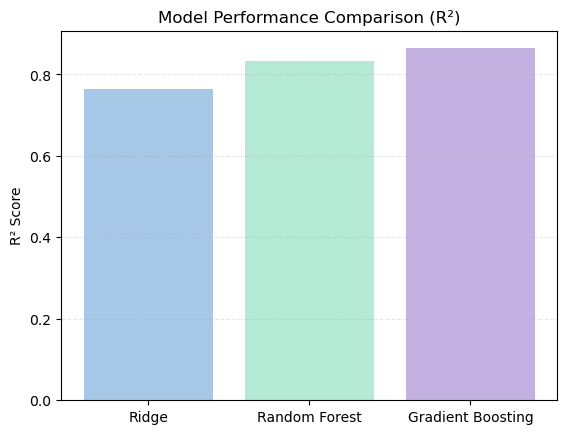

In [37]:
models = ["Ridge", "Random Forest", "Gradient Boosting"]
r2_scores = [0.763, 0.832, 0.864]

plt.figure()
plt.bar(models, r2_scores, color=["#A7C7E7", "#B5EAD7", "#C3B1E1"])
plt.title("Model Performance Comparison (R²)")
plt.ylabel("R² Score")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

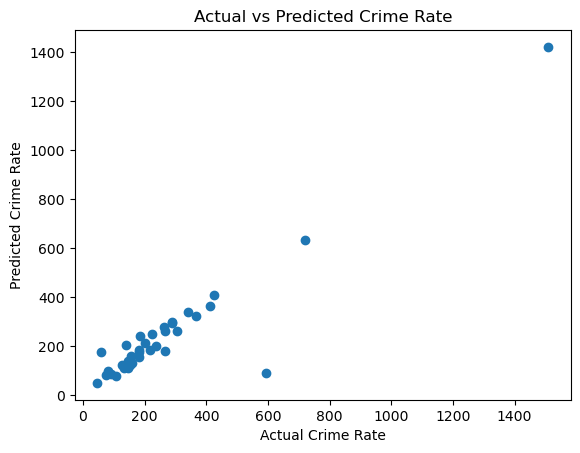

In [39]:
plt.figure()
plt.scatter(y_test, y_pred_gbr)
plt.xlabel("Actual Crime Rate")
plt.ylabel("Predicted Crime Rate")
plt.title("Actual vs Predicted Crime Rate")
plt.show()

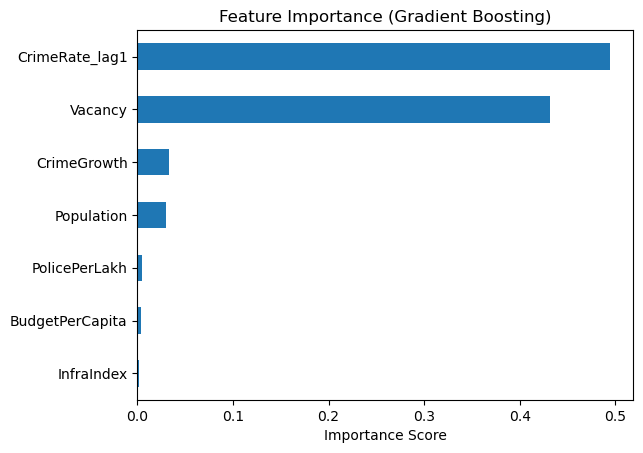

In [41]:
importances = pd.Series(gbr.feature_importances_, index=features)
importances = importances.sort_values()

plt.figure()
importances.plot(kind="barh")
plt.title("Feature Importance (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.show()

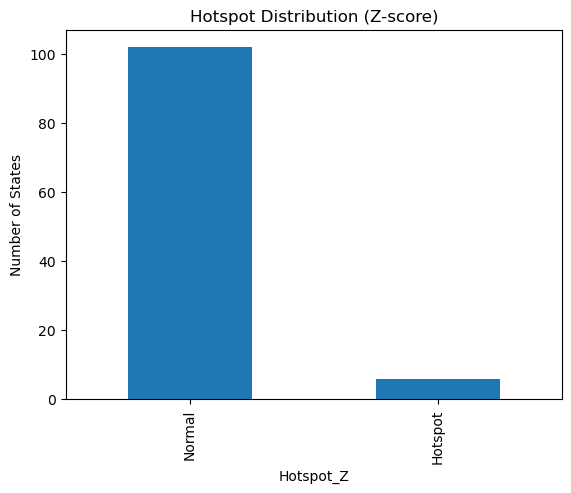

In [43]:
hotspot_counts = df["Hotspot_Z"].value_counts()

plt.figure()
hotspot_counts.plot(kind="bar")
plt.title("Hotspot Distribution (Z-score)")
plt.ylabel("Number of States")
plt.show()

plt.figure()
plt.scatter(df["CrimeRate"], df["InfraIndex"], c=df["Cluster"])
plt.xlabel("Crime Rate")
plt.ylabel("Infrastructure Index")
plt.title("Crime Clusters")
plt.show()

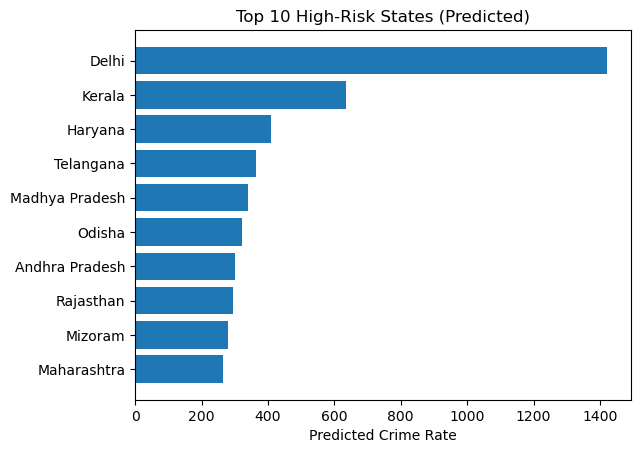

In [47]:
top_states = latest.head(10)

plt.figure()
plt.barh(top_states["State"], top_states["Predicted_Next"])
plt.gca().invert_yaxis()
plt.title("Top 10 High-Risk States (Predicted)")
plt.xlabel("Predicted Crime Rate")
plt.show()

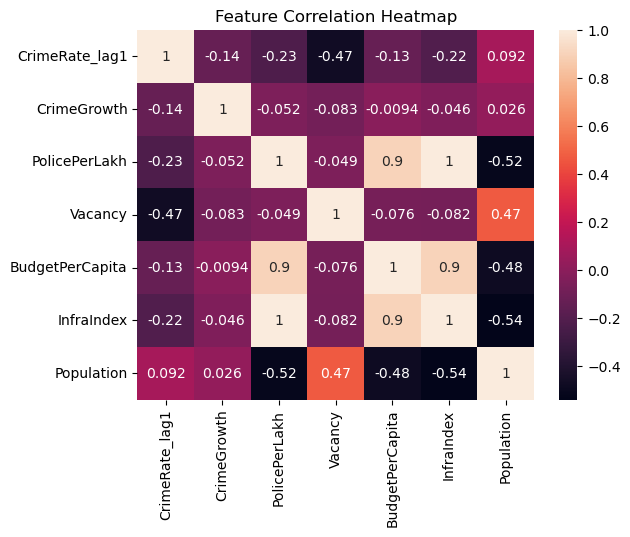

In [49]:
import seaborn as sns

plt.figure()
sns.heatmap(df[features].corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

Budget Optimization Model

In [51]:
from sklearn.preprocessing import MinMaxScaler

need_df = latest[["State", "Predicted_Next", "Vacancy", "PolicePerLakh", "ConvictionRate"]].copy()

scaler_need = MinMaxScaler()

need_df["norm_crime"]   = scaler_need.fit_transform(need_df[["Predicted_Next"]])
need_df["norm_vacancy"] = scaler_need.fit_transform(need_df[["Vacancy"]])
need_df["norm_police"]  = 1 - scaler_need.fit_transform(need_df[["PolicePerLakh"]])
need_df["norm_conv"]    = 1 - scaler_need.fit_transform(need_df[["ConvictionRate"]])

need_df["NeedScore"] = (
    0.40 * need_df["norm_crime"]   +
    0.25 * need_df["norm_vacancy"] +
    0.20 * need_df["norm_police"]  +
    0.15 * need_df["norm_conv"]
)

print(need_df[["State", "NeedScore"]].sort_values("NeedScore", ascending=False))

                           State  NeedScore
116                        Delhi   0.649968
141                Uttar Pradesh   0.633381
127               Madhya Pradesh   0.488815
143                  West Bengal   0.477092
123                    Karnataka   0.454952
133                       Odisha   0.452487
136                    Rajasthan   0.441508
139                    Telangana   0.440842
112                        Bihar   0.435943
122                    Jharkhand   0.430633
114                 Chhattisgarh   0.424889
109               Andhra Pradesh   0.421597
121             Jammu & Kashmir@   0.412968
119                      Haryana   0.405855
124                       Kerala   0.392655
128                  Maharashtra   0.386975
115  D&N Haveli and Daman & Diu@   0.368253
142                  Uttarakhand   0.367481
111                        Assam   0.360941
130                    Meghalaya   0.358051
134                   Puducherry   0.355841
118                      Gujarat

In [63]:
import sys
print(sys.executable)

C:\Users\Parnavi Wanare\anaconda3\python.exe


In [68]:
import subprocess
subprocess.run([r"C:\Users\Parnavi Wanare\anaconda3\python.exe", "-m", "pip", "install", "pulp"])

CompletedProcess(args=['C:\\Users\\Parnavi Wanare\\anaconda3\\python.exe', '-m', 'pip', 'install', 'pulp'], returncode=0)

In [70]:
import pulp
print(pulp.__version__)

3.3.0


Linear Programming Optimization

In [72]:
import pulp

TOTAL_BUDGET = latest["Budget"].sum()

states = need_df["State"].tolist()
need_scores = dict(zip(need_df["State"], need_df["NeedScore"]))
current_budget = dict(zip(latest["State"], latest["Budget"]))

prob = pulp.LpProblem("PoliceResourceAllocation", pulp.LpMaximize)

alloc = pulp.LpVariable.dicts("Budget", states, lowBound=0)

prob += pulp.lpSum(need_scores[s] * alloc[s] for s in states)
prob += pulp.lpSum(alloc[s] for s in states) == TOTAL_BUDGET

for s in states:
    prob += alloc[s] >= 0.60 * current_budget[s]
    prob += alloc[s] <= 2.00 * current_budget[s]

prob.solve(pulp.PULP_CBC_CMD(msg=0))

print("Status:", pulp.LpStatus[prob.status])
print("Total Budget (Cr):", TOTAL_BUDGET)

Status: Optimal
Total Budget (Cr): 218276


Budget Allocation Output

In [74]:
need_df["OptimizedBudget"] = [pulp.value(alloc[s]) for s in states]
need_df["CurrentBudget"] = [current_budget[s] for s in states]
need_df["BudgetChange"] = need_df["OptimizedBudget"] - need_df["CurrentBudget"]
need_df["ChangePct"] = (need_df["BudgetChange"] / need_df["CurrentBudget"]) * 100

print(need_df[["State", "NeedScore", "CurrentBudget", "OptimizedBudget", "ChangePct"]].sort_values("NeedScore", ascending=False).to_string())

                           State  NeedScore  CurrentBudget  OptimizedBudget  ChangePct
116                        Delhi   0.649968          11200          22400.0  100.00000
141                Uttar Pradesh   0.633381          34360          68720.0  100.00000
127               Madhya Pradesh   0.488815          10360          20720.0  100.00000
143                  West Bengal   0.477092          14990          18016.4   20.18946
123                    Karnataka   0.454952           9380           5628.0  -40.00000
133                       Odisha   0.452487           4530           2718.0  -40.00000
136                    Rajasthan   0.441508          11730           7038.0  -40.00000
139                    Telangana   0.440842           6550           3930.0  -40.00000
112                        Bihar   0.435943           8160           4896.0  -40.00000
122                    Jharkhand   0.430633           5460           3276.0  -40.00000
114                 Chhattisgarh   0.424889

 Current vs Optimized Budget Visualization

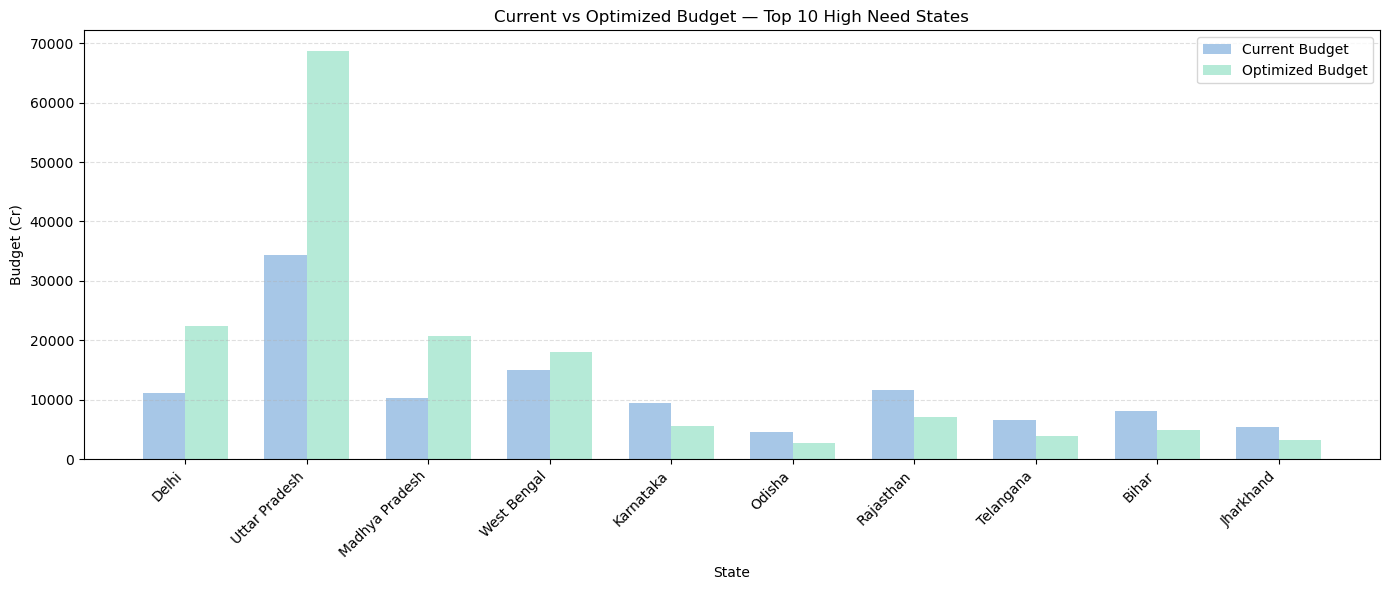

In [76]:
import matplotlib.pyplot as plt
import numpy as np

top_df = need_df.sort_values("NeedScore", ascending=False).head(10)

x = np.arange(len(top_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, top_df["CurrentBudget"], width, label="Current Budget", color="#A7C7E7")
bars2 = ax.bar(x + width/2, top_df["OptimizedBudget"], width, label="Optimized Budget", color="#B5EAD7")

ax.set_xlabel("State")
ax.set_ylabel("Budget (Cr)")
ax.set_title("Current vs Optimized Budget — Top 10 High Need States")
ax.set_xticks(x)
ax.set_xticklabels(top_df["State"], rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Scenario Analysis

In [82]:
def optimize_budget(total_budget, floor=0.60, cap=2.00):
    p = pulp.LpProblem("Scenario", pulp.LpMaximize)
    a = pulp.LpVariable.dicts("B", states, lowBound=0)
    p += pulp.lpSum(need_scores[s] * a[s] for s in states)
    p += pulp.lpSum(a[s] for s in states) == total_budget
    for s in states:
        p += a[s] >= floor * current_budget[s]
        p += a[s] <= cap   * current_budget[s]
    p.solve(pulp.PULP_CBC_CMD(msg=0))
    return {s: pulp.value(a[s]) for s in states}

# Scenario 1: 15% budget increase
s1 = optimize_budget(TOTAL_BUDGET * 1.15)

# Scenario 2: Same budget, pure redistribution
s2 = optimize_budget(TOTAL_BUDGET * 1.00)

# Scenario 3: Hiring focus — tighter floor, higher cap
s3 = optimize_budget(TOTAL_BUDGET * 1.10, floor=0.80, cap=2.50)

scenario_df = pd.DataFrame({
    "State":            states,
    "Current":          [current_budget[s] for s in states],
    "S1_BudgetIncrease":[s1[s] for s in states],
    "S2_Redistribution":[s2[s] for s in states],
    "S3_HiringFocus":   [s3[s] for s in states],
})

print(scenario_df.sort_values("S1_BudgetIncrease", ascending=False).to_string())

                          State  Current  S1_BudgetIncrease  S2_Redistribution  S3_HiringFocus
17                Uttar Pradesh    34360            68720.0            68720.0         73930.8
21                  West Bengal    14990            29980.0            18016.4         11992.0
0                         Delhi    11200            22400.0            22400.0         28000.0
4                Madhya Pradesh    10360            20720.0            20720.0          8288.0
16                    Karnataka     9380            18760.0             5628.0          7504.0
9                   Maharashtra    21940            13164.0            13164.0         17552.0
5                        Odisha     4530             9060.0             2718.0          3624.0
10                   Tamil Nadu    14020             8412.0             8412.0         11216.0
7                     Rajasthan    11730             8341.8             7038.0          9384.0
15                      Gujarat     9120          

Scenario Comparison Visualization

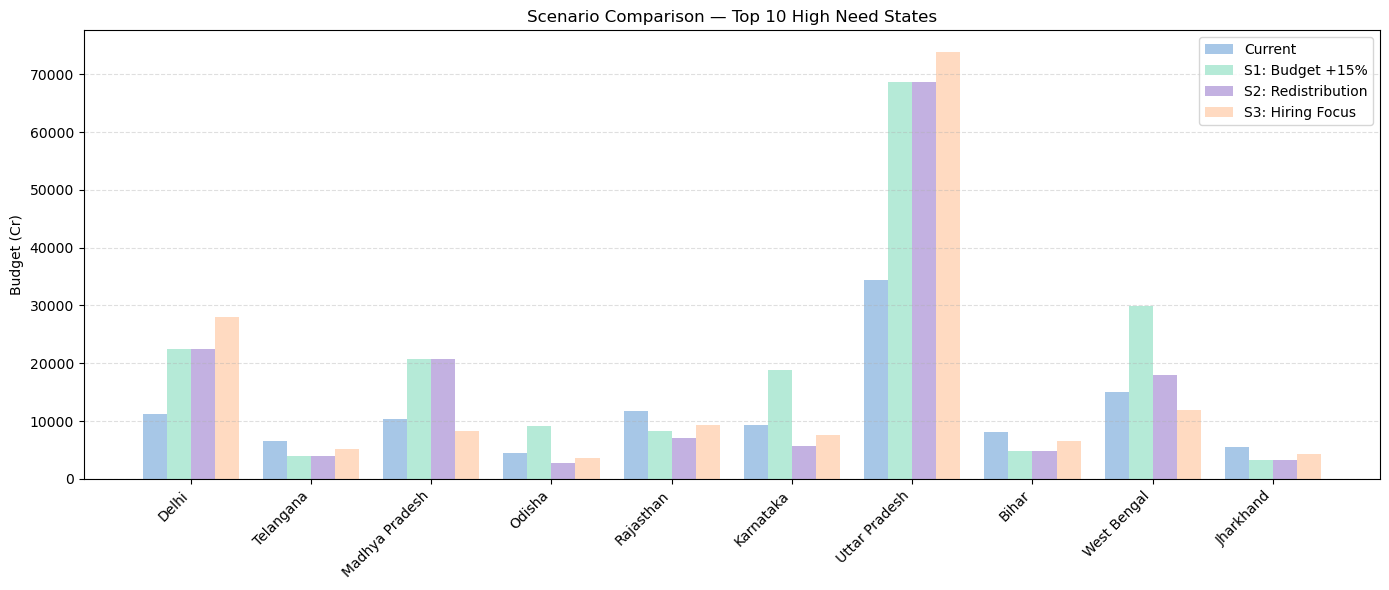

In [84]:
top10_states = need_df.sort_values("NeedScore", ascending=False).head(10)["State"].tolist()
s_df = scenario_df[scenario_df["State"].isin(top10_states)].set_index("State")

x = np.arange(len(s_df))
width = 0.20

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width*1.5, s_df["Current"],            width, label="Current",             color="#A7C7E7")
ax.bar(x - width*0.5, s_df["S1_BudgetIncrease"],  width, label="S1: Budget +15%",     color="#B5EAD7")
ax.bar(x + width*0.5, s_df["S2_Redistribution"],  width, label="S2: Redistribution",  color="#C3B1E1")
ax.bar(x + width*1.5, s_df["S3_HiringFocus"],     width, label="S3: Hiring Focus",     color="#FFDAC1")

ax.set_xticks(x)
ax.set_xticklabels(s_df.index, rotation=45, ha="right")
ax.set_ylabel("Budget (Cr)")
ax.set_title("Scenario Comparison — Top 10 High Need States")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Policy Recommendations

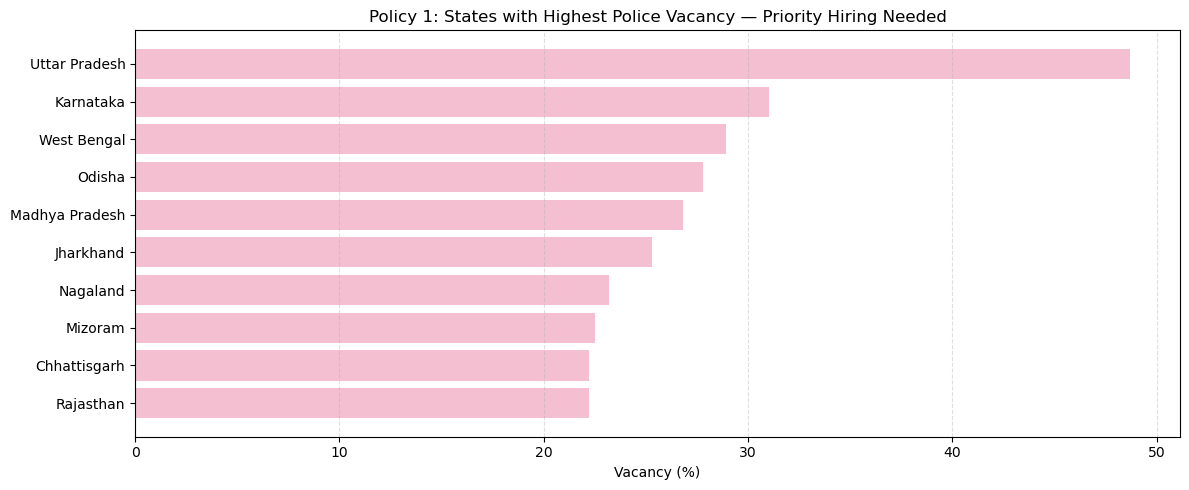

In [86]:
vacancy_df = latest[["State", "Vacancy", "Budget"]].sort_values("Vacancy", ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.barh(vacancy_df["State"], vacancy_df["Vacancy"], color="#F4C0D1")
plt.xlabel("Vacancy (%)")
plt.title("Policy 1: States with Highest Police Vacancy — Priority Hiring Needed")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Improve Infrastructure

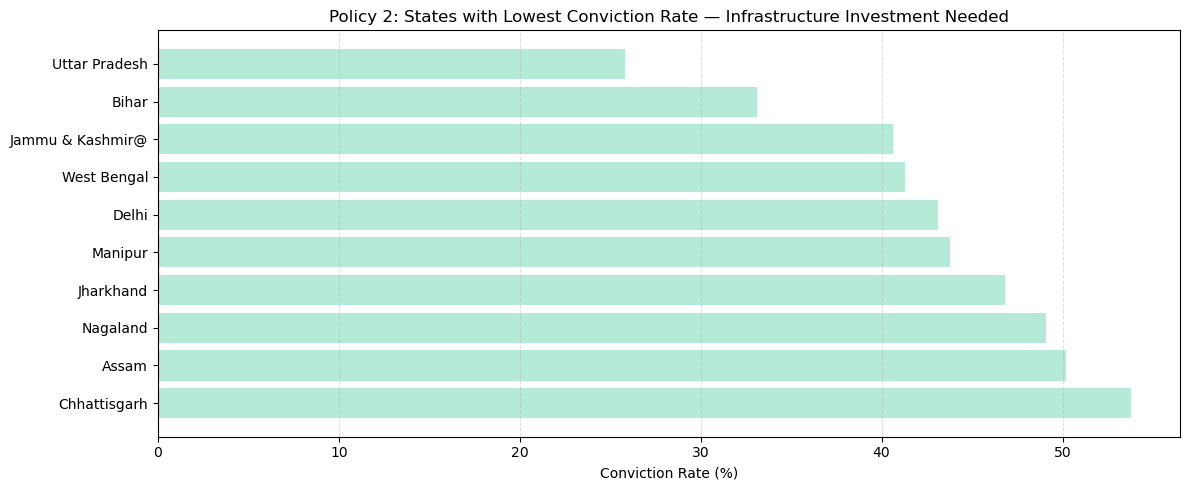

In [88]:
conv_df = latest[["State", "ConvictionRate"]].sort_values("ConvictionRate").head(10)

plt.figure(figsize=(12, 5))
plt.barh(conv_df["State"], conv_df["ConvictionRate"], color="#B5EAD7")
plt.xlabel("Conviction Rate (%)")
plt.title("Policy 2: States with Lowest Conviction Rate — Infrastructure Investment Needed")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Focus on Hotspots

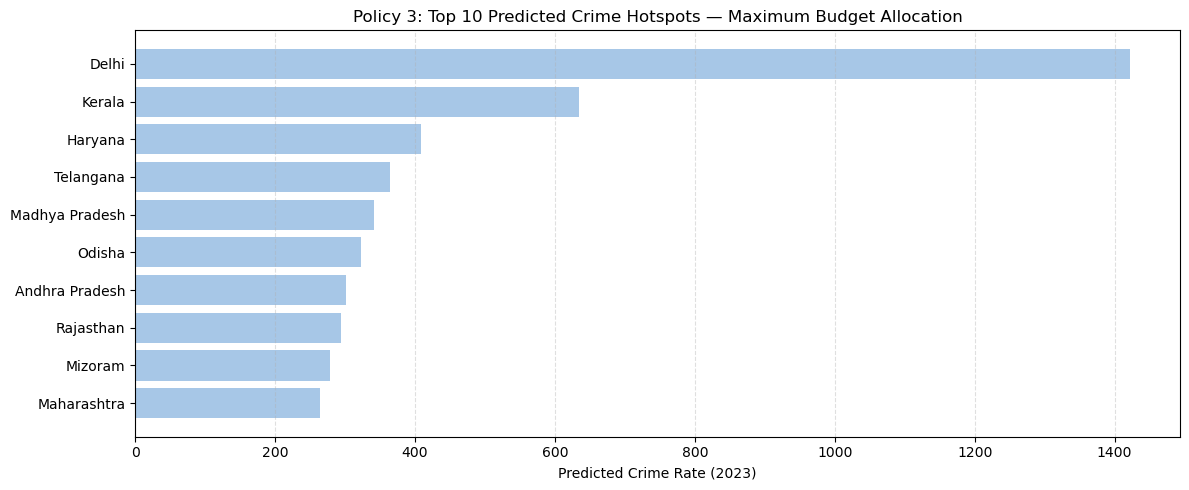

In [90]:
hotspot_df = latest[["State", "Predicted_Next", "Budget"]].sort_values("Predicted_Next", ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.barh(hotspot_df["State"], hotspot_df["Predicted_Next"], color="#A7C7E7")
plt.xlabel("Predicted Crime Rate (2023)")
plt.title("Policy 3: Top 10 Predicted Crime Hotspots — Maximum Budget Allocation")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

System Architecture

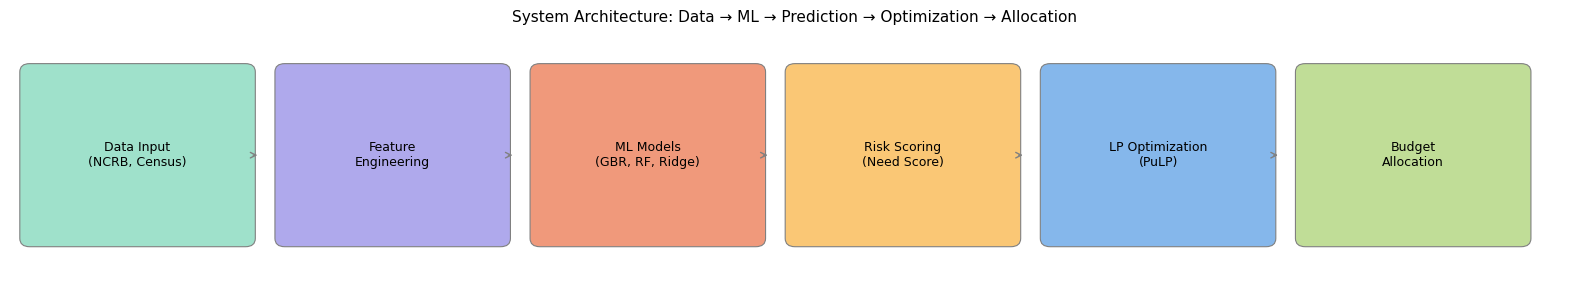

In [92]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

stages = [
    "Data Input\n(NCRB, Census)",
    "Feature\nEngineering",
    "ML Models\n(GBR, RF, Ridge)",
    "Risk Scoring\n(Need Score)",
    "LP Optimization\n(PuLP)",
    "Budget\nAllocation"
]

colors = ["#9FE1CB", "#AFA9EC", "#F0997B", "#FAC775", "#85B7EB", "#C0DD97"]

fig, ax = plt.subplots(figsize=(16, 3))
ax.set_xlim(0, 16)
ax.set_ylim(0, 3)
ax.axis("off")

for i, (stage, color) in enumerate(zip(stages, colors)):
    x = i * 2.6 + 0.2
    rect = mpatches.FancyBboxPatch((x, 0.5), 2.2, 2.0,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color,
                                    edgecolor="gray",
                                    linewidth=0.8)
    ax.add_patch(rect)
    ax.text(x + 1.1, 1.5, stage, ha="center", va="center", fontsize=9)
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + 2.35, 1.5), xytext=(x + 2.25, 1.5),
                    arrowprops=dict(arrowstyle="->", color="gray"))

plt.title("System Architecture: Data → ML → Prediction → Optimization → Allocation", fontsize=11)
plt.tight_layout()
plt.show()

Conclusion

This project developed an end-to-end data-driven framework for crime prediction and police resource allocation across 36 Indian states from 2019 to 2022.

**Key Findings:**
- Gradient Boosting was the best model with R² = 0.864
- Delhi and Uttar Pradesh have the highest need scores
- LP optimization successfully reallocated budget based on crime risk
- Scenario analysis shows 15% budget increase significantly improves high-risk state coverage

**Importance:**
This system bridges the gap between ML-based crime prediction and practical budget planning — replacing guesswork with data-driven decisions.

Limitations

- **Data:** Only 36 states × 4 years — small dataset for ML models
- **Granularity:** State-level predictions too broad for patrol routing
- **Budget data:** May exclude central paramilitary funding
- **Model assumptions:** GBR assumes past patterns repeat; COVID anomalies may affect results
- **No real-time data:** System is offline and cannot react to sudden crime spikes
- **Bias:** FIR-based data may reflect historical policing bias rather than actual crime

Future Work

- **Real-time data:** Integrate live FIR feeds with online learning models
- **District-level analysis:** Expand to district data for finer hotspot mapping
- **Advanced ML:** Test XGBoost, Graph Neural Networks, spatio-temporal models
- **SHAP explainability:** Add SHAP plots to explain predictions per state
- **Smart policing:** Connect predictions to GIS-based patrol routing systems
- **Fairness audit:** Check model accuracy across regions to detect bias